In [25]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [26]:
SEED=42
torch.manual_seed(SEED)
np.random.seed(SEED)

Load MNIST data

In [27]:
transform=transforms.Compose([transforms.ToTensor(),])
train_data=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_data=datasets.MNIST(root='./data',train=False,transform=transform)

train_loader=DataLoader(train_data,batch_size=64,shuffle=True)
test_loader=DataLoader(test_data,batch_size=64)

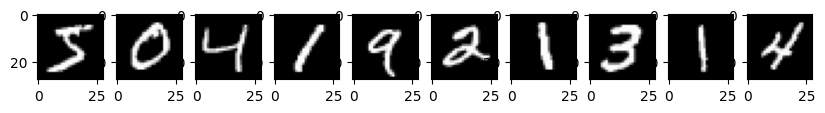

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
for i in range(10):
  plt.subplot(1, 10, i + 1)
  # Corrected line: squeeze the channel dimension, convert to numpy, and display
  plt.imshow(train_data[i][0].squeeze(0).numpy(), cmap='grey')
  # plt.axis('off') # Hide axes for cleaner display
plt.show()

Creating the Architecture

In [29]:
class LeNET(nn.Module):
  def __init__(self):
    super().__init__()
    #Layer 1
    self.conv1=nn.Conv2d(in_channels=1,out_channels=6,kernel_size=5)
    self.pool=nn.AvgPool2d(kernel_size=2,stride=1) #sub-sampling layer

    #Layer 2
    self.conv2=nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5)

    #Layer 3
    self.conv3=nn.Conv2d(in_channels=16,out_channels=120,kernel_size=5)

    # fully connected layer
    self.fc1=nn.Linear(in_features=20280,out_features=84)
    self.fc2=nn.Linear(in_features=84,out_features=10)

  def scaled_tanh(self,x):
    return 1.7159*torch.tanh(2/3 * x)

  def forward(self,x):
    x=self.pool(self.scaled_tanh(self.conv1(x)))
    x=self.pool(self.scaled_tanh(self.conv2(x)))
    x=self.pool(self.scaled_tanh(self.conv3(x)))
    x=torch.flatten(x,start_dim=1)
    x=self.scaled_tanh(self.fc1(x))
    x=self.fc2(x)
    return x

Creating the Traning and Testing loop

In [30]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=LeNET().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [32]:
EPOCHS=20
for epoch in range(EPOCHS):
  model.train()
  total_loss=0

  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  print(f"The total Loss for epoch: {epoch+1} is: {total_loss:.3f}")
  avg_loss_per_epoch = total_loss / len(train_loader)
  print(f"The average loss for epoch: {epoch+1} is: {avg_loss_per_epoch:.3f}")

The total Loss for epoch: 1 is: 265.322
The average loss for epoch: 1 is: 0.283
The total Loss for epoch: 2 is: 247.932
The average loss for epoch: 2 is: 0.264
The total Loss for epoch: 3 is: 211.560
The average loss for epoch: 3 is: 0.226
The total Loss for epoch: 4 is: 181.007
The average loss for epoch: 4 is: 0.193
The total Loss for epoch: 5 is: 161.211
The average loss for epoch: 5 is: 0.172
The total Loss for epoch: 6 is: 148.267
The average loss for epoch: 6 is: 0.158
The total Loss for epoch: 7 is: 142.261
The average loss for epoch: 7 is: 0.152
The total Loss for epoch: 8 is: 131.642
The average loss for epoch: 8 is: 0.140
The total Loss for epoch: 9 is: 126.510
The average loss for epoch: 9 is: 0.135
The total Loss for epoch: 10 is: 133.606
The average loss for epoch: 10 is: 0.142
The total Loss for epoch: 11 is: 123.063
The average loss for epoch: 11 is: 0.131
The total Loss for epoch: 12 is: 118.669
The average loss for epoch: 12 is: 0.127
The total Loss for epoch: 13 is: 1

In [33]:
model.eval()
correct=0
total=0
with torch.inference_mode():
  for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    output=model(images)
    _,predict=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predict==labels).sum().item()
print(f"The accuracy of model is: {100*correct/total:.3f}")

The accuracy of model is: 95.950
